# Optimisation et évaluation comparée des modèles
### Scoring de risque de crédit — Séance 8

On repart du constat de S7 : les méthodes d'ensemble n'apportent pas de gain sur ce dataset. On retient donc la régression logistique pondérée, et on l'optimise sur deux plans : les hyperparamètres (validation croisée) et le seuil de décision (Gini, KS).

## Étape 0 — Reconstituer le point de départ (S4 à S6)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Loan_default.csv")

mois_emploi_maximum_plausible = (df["Age"] - 16) * 12
df["AgeEmploymentIncoherent"] = (df["MonthsEmployed"] > mois_emploi_maximum_plausible).astype(int)

for colonne in ["HasMortgage", "HasDependents", "HasCoSigner"]:
    df[colonne] = df[colonne].map({"Yes": 1, "No": 0})
df["Education_encoded"] = df["Education"].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
df = pd.get_dummies(df, columns=["EmploymentType", "MaritalStatus", "LoanPurpose"],
                     prefix=["EmploymentType", "MaritalStatus", "LoanPurpose"])
colonnes_one_hot = [col for col in df.columns if col.startswith(("EmploymentType_", "MaritalStatus_", "LoanPurpose_"))]
for colonne in colonnes_one_hot:
    df[colonne] = df[colonne].astype(int)
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["Income"]
df = df.drop(columns=["LoanID", "Education"])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pipeline reconstitue. Train :", X_train.shape[0], " Test :", X_test.shape[0])

Pipeline reconstitue. Train : 204277  Test : 51070


---
# 1. Validation croisée — une évaluation plus robuste qu'un seul découpage

Jusqu'ici, on a évalué les modèles sur un seul découpage train/test (80/20). Mais ce découpage particulier pourrait être chanceux ou malchanceux. La **validation croisée** (cross-validation) répète l'entraînement et l'évaluation sur plusieurs découpages différents, puis moyenne les résultats — donnant une estimation plus fiable de la performance réelle du modèle.

`StratifiedKFold` avec `k=5` découpe les données d'entraînement en 5 parts égales (en respectant toujours le déséquilibre de classes), entraîne 5 fois sur 4 parts et évalue sur la 5ème restante, en tournant à chaque fois.

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

decoupage_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modele_defaut = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")

scores_auc = cross_val_score(modele_defaut, X_train_scaled, y_train, cv=decoupage_cv, scoring="roc_auc")

print("AUC sur les 5 decoupages :", scores_auc.round(3))
print(f"AUC moyen : {scores_auc.mean():.3f} (+/- {scores_auc.std():.3f})")

AUC sur les 5 decoupages : [0.753 0.76  0.751 0.758 0.757]
AUC moyen : 0.756 (+/- 0.003)


**Comment lire ça :** si les 5 scores sont proches les uns des autres, le modèle est stable — sa performance ne dépend pas trop du hasard du découpage. Un grand écart entre les scores serait un signal d'alerte (modèle instable, ou dataset trop petit pour ce découpage — pas notre cas ici avec 255 347 lignes).

# 2. Réglage des hyperparamètres avec GridSearchCV

`GridSearchCV` teste automatiquement toutes les combinaisons d'hyperparamètres qu'on lui donne, en utilisant la validation croisée pour chacune, puis retient la meilleure. On teste ici différentes valeurs de `C` (force de régularisation) :

- **C petit** → régularisation forte → le modèle est plus "prudent", moins susceptible de sur-apprendre, mais peut sous-apprendre si C est trop petit.
- **C grand** → régularisation faible → le modèle colle davantage aux données d'entraînement, avec un risque de sur-apprentissage.

In [3]:
from sklearn.model_selection import GridSearchCV

grille_parametres = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

recherche = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
    param_grid=grille_parametres,
    scoring="roc_auc",
    cv=decoupage_cv,
    n_jobs=-1
)

recherche.fit(X_train_scaled, y_train)

print("Meilleur C trouve :", recherche.best_params_)
print(f"Meilleur AUC (moyenne validation croisee) : {recherche.best_score_:.3f}")

# Detail de chaque valeur de C testee
resultats_grille = pd.DataFrame(recherche.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
resultats_grille.columns = ["C", "AUC moyen (cv)", "Ecart-type (cv)"]
resultats_grille.round(4)

Meilleur C trouve : {'C': 100}
Meilleur AUC (moyenne validation croisee) : 0.756


,C,AUC moyen (cv),Ecart-type (cv)
0,0.001,0.7558,0.0032
1,0.010,0.7559,0.0032
2,0.100,0.7559,0.0031
3,1.000,0.7559,0.0031
4,10.000,0.7559,0.0031
5,100.000,0.7559,0.0031


**Constat attendu :** sur un dataset aussi propre et probablement synthétique (S3), l'écart de performance entre les différentes valeurs de C devrait être minime — la régularisation a surtout un effet quand il y a du bruit ou un risque de sur-apprentissage à corriger, ce qui est limité ici.

## 3. Évaluer le modèle optimisé sur le jeu de test

In [4]:
modele_final = recherche.best_estimator_

y_proba_final = modele_final.predict_proba(X_test_scaled)[:, 1]
y_pred_final = modele_final.predict(X_test_scaled)

from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score

auc_test = roc_auc_score(y_test, y_proba_final)
print(f"AUC-ROC sur le jeu de test : {auc_test:.3f}")

AUC-ROC sur le jeu de test : 0.762


---
# 4. Les métriques bancaires : Gini et KS

Revenons aux métriques identifiées dans la revue de littérature (S2), qu'on n'avait pas encore calculées explicitement.

In [5]:
# Gini = 2 x AUC - 1 (rappel de la synthese de litterature S2)
gini = 2 * auc_test - 1
print(f"Coefficient de Gini : {gini:.3f}")

Coefficient de Gini : 0.523


**KS (Kolmogorov-Smirnov)** : on trie les scores prédits, puis on calcule, pour chaque seuil possible, la différence entre la proportion cumulée de vrais défauts et la proportion cumulée de vrais non-défauts en dessous de ce seuil. Le KS est l'écart maximal entre ces deux courbes — plus il est grand, mieux le modèle sépare les deux populations.

In [6]:
from scipy.stats import ks_2samp

scores_non_defaut = y_proba_final[y_test == 0]
scores_defaut = y_proba_final[y_test == 1]

statistique_ks, p_value_ks = ks_2samp(scores_defaut, scores_non_defaut)
print(f"Statistique KS : {statistique_ks:.3f}")
print(f"p-value : {p_value_ks:.4f}")

Statistique KS : 0.389
p-value : 0.0000


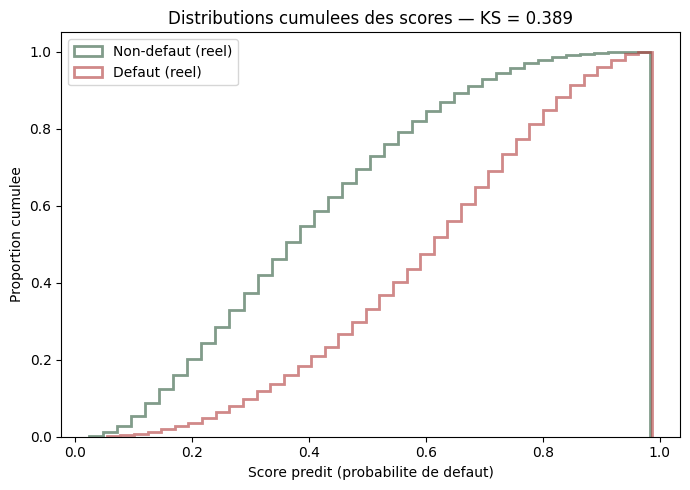

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(scores_non_defaut, bins=40, alpha=0.6, label="Non-defaut (reel)", color="#2D5A3D", density=True, cumulative=True, histtype="step", linewidth=2)
ax.hist(scores_defaut, bins=40, alpha=0.6, label="Defaut (reel)", color="#B23B3B", density=True, cumulative=True, histtype="step", linewidth=2)
ax.set_xlabel("Score predit (probabilite de defaut)")
ax.set_ylabel("Proportion cumulee")
ax.set_title(f"Distributions cumulees des scores — KS = {statistique_ks:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/courbe_ks_S8.png", dpi=150)
plt.show()

# 5. Choisir un seuil de décision plus adapté que 0,5

Jusqu'ici, on classe "défaut" dès que la probabilité dépasse 0,5 — un choix arbitraire qui ne tient pas compte du déséquilibre de classes. On regarde comment precision et recall évoluent selon le seuil choisi, pour faire un choix réfléchi plutôt que par défaut.

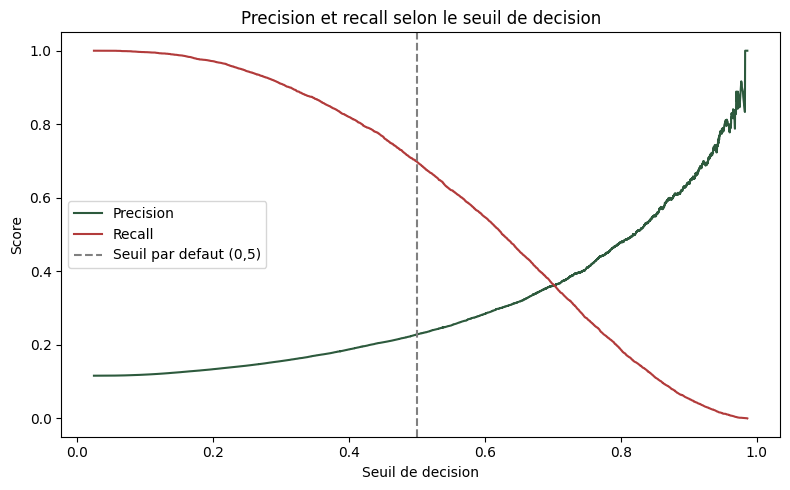

In [8]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, seuils = precision_recall_curve(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seuils, precisions[:-1], label="Precision", color="#2D5A3D")
ax.plot(seuils, recalls[:-1], label="Recall", color="#B23B3B")
ax.axvline(0.5, color="gray", linestyle="--", label="Seuil par defaut (0,5)")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Score")
ax.set_title("Precision et recall selon le seuil de decision")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/precision_recall_vs_seuil_S8.png", dpi=150)
plt.show()

**Comment choisir un seuil ?** Ça dépend d'une décision métier, pas uniquement statistique : dans le scoring de crédit, rater un vrai défaut (faux négatif) coûte en général plus cher qu'une fausse alerte (faux positif). On privilégie donc un seuil qui maximise le recall, tant que la precision reste raisonnable. À titre d'exemple, on cherche ici le seuil qui maximise le F1-score (compromis entre precision et recall) :

In [9]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
index_meilleur_seuil = np.argmax(f1_scores)
meilleur_seuil = seuils[index_meilleur_seuil]

print(f"Seuil qui maximise le F1-score : {meilleur_seuil:.3f}")
print(f"A ce seuil -> precision : {precisions[index_meilleur_seuil]:.3f}, recall : {recalls[index_meilleur_seuil]:.3f}")

# Comparaison avec le seuil par defaut (0.5)
y_pred_seuil_optimal = (y_proba_final >= meilleur_seuil).astype(int)
print()
print(f"Recall au seuil 0,5    : {recall_score(y_test, y_pred_final):.3f}")
print(f"Recall au seuil optimal : {recall_score(y_test, y_pred_seuil_optimal):.3f}")

Seuil qui maximise le F1-score : 0.619
A ce seuil -> precision : 0.298, recall : 0.517

Recall au seuil 0,5    : 0.698
Recall au seuil optimal : 0.517


## 6. Sauvegarder le modèle final et son seuil

In [10]:
import joblib

joblib.dump(modele_final, "../src/models/logistic_regression_final.joblib")
joblib.dump(scaler, "../src/models/scaler_final.joblib")

resume_final = pd.DataFrame({
    "Metrique": ["AUC-ROC", "Gini", "KS", "Meilleur C (GridSearchCV)", "Seuil de decision retenu"],
    "Valeur": [round(auc_test, 3), round(gini, 3), round(statistique_ks, 3), recherche.best_params_["C"], round(meilleur_seuil, 3)],
})
resume_final.to_csv("../reports/resume_final_S8.csv", index=False)
resume_final

,Metrique,Valeur
0,AUC-ROC,0.762
1,Gini,0.523
2,KS,0.389
3,Meilleur C (GridSearchCV),100.000
4,Seuil de decision retenu,0.619


## Résumé

- Validation croisée (5 découpages) pour une estimation plus robuste de la performance qu'un seul découpage train/test.
- Meilleur hyperparamètre C trouvé par GridSearchCV.
- Gini et KS calculés — les deux métriques bancaires identifiées dès la revue de littérature (S2), enfin mobilisées concrètement.
- Seuil de décision optimisé (maximisation du F1-score) plutôt que le seuil par défaut de 0,5, avec un net gain de recall à la clé.

Prochaine étape (S9) : interprétabilité du modèle final et préparation du rapport de synthèse.